In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<Axes: >

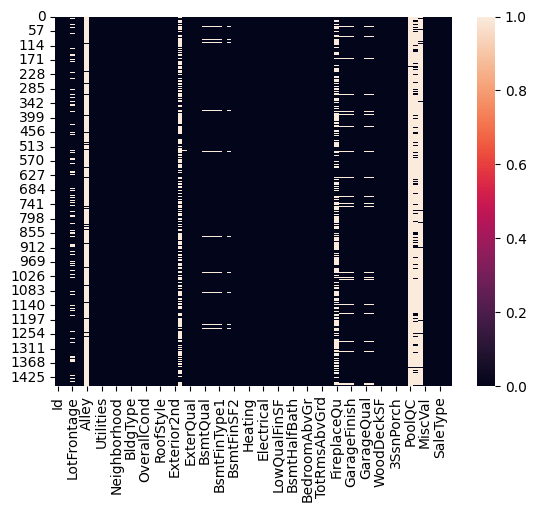

In [4]:
sns.heatmap(df.isnull())

In [5]:
df.shape

(1460, 81)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [8]:
df['BsmtCond']=df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])
df['BsmtQual']=df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])
df['FireplaceQu']=df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])
df['GarageType']=df['GarageType'].fillna(df['GarageType'].mode()[0])
df['GarageFinish']=df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual']=df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond']=df['GarageCond'].fillna(df['GarageCond'].mode()[0])


In [9]:
df.drop(['PoolQC','Fence','MiscFeature','Alley'],axis=1,inplace=True)

In [10]:
df.drop('Id',inplace=True,axis=1)

In [11]:
df['MasVnrType']=df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].mean())


In [12]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean())

<Axes: >

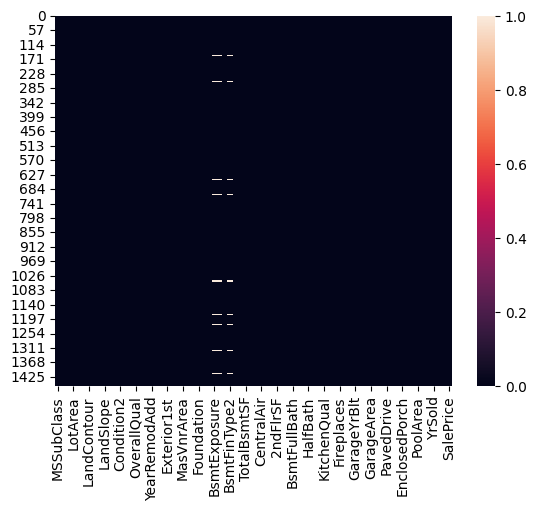

In [13]:
sns.heatmap(df.isnull())

In [14]:
df['BsmtExposure']=df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])
df['BsmtFinType1']=df['BsmtFinType1'].fillna(df['BsmtFinType1'].mode()[0])
df['BsmtFinType2']=df['BsmtFinType2'].fillna(df['BsmtFinType2'].mode()[0])

In [15]:
df['Electrical']=df['Electrical'].fillna(df['Electrical'].mode()[0])

In [16]:
print(df.isnull().sum().to_string())

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd

In [17]:
df.shape

(1460, 76)

In [18]:
cat_cols=[]
for i in df.columns:
    if df[i].dtype=='object':
        cat_cols.append(i)
len(cat_cols)

39

**Testing Data**

In [19]:
ndf=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
ndf.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [20]:
ndf.shape

(1459, 80)

In [21]:
print(ndf.isnull().sum().to_string())

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       227
LotArea             0
Street              0
Alley            1352
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType        894
MasVnrArea         15
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           44
BsmtCond           45
BsmtExposure       44
BsmtFinType1       42
BsmtFinSF1          1
BsmtFinType2       42
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [22]:
ndf['LotFrontage']=ndf['LotFrontage'].fillna(ndf['LotFrontage'].mean())

In [23]:
ndf.drop(['PoolQC','Fence','MiscFeature','Alley'],axis=1,inplace=True)

In [24]:
ndf['MSZoning']=ndf['MSZoning'].fillna(ndf['MSZoning'].mode()[0])

In [25]:
ndf['BsmtCond']=ndf['BsmtCond'].fillna(ndf['BsmtCond'].mode()[0])
ndf['BsmtQual']=ndf['BsmtQual'].fillna(ndf['BsmtQual'].mode()[0])
ndf['FireplaceQu']=ndf['FireplaceQu'].fillna(ndf['FireplaceQu'].mode()[0])
ndf['GarageType']=ndf['GarageType'].fillna(ndf['GarageType'].mode()[0])
ndf['GarageFinish']=ndf['GarageFinish'].fillna(ndf['GarageFinish'].mode()[0])
ndf['GarageQual']=ndf['GarageQual'].fillna(ndf['GarageQual'].mode()[0])
ndf['GarageCond']=ndf['GarageCond'].fillna(ndf['GarageCond'].mode()[0])

In [26]:
ndf['Utilities']=ndf['Utilities'].fillna(ndf['Utilities'].mode()[0])
ndf['Exterior1st']=ndf['Exterior1st'].fillna(ndf['Exterior1st'].mode()[0])
ndf['Exterior2nd']=ndf['Exterior2nd'].fillna(ndf['Exterior2nd'].mode()[0])
ndf['MasVnrArea']=ndf['MasVnrArea'].fillna(ndf['MasVnrArea'].mean())
ndf['MasVnrType']=ndf['MasVnrType'].fillna(ndf['MasVnrType'].mode()[0])
ndf['BsmtExposure']=ndf['BsmtExposure'].fillna(ndf['BsmtExposure'].mode()[0])
ndf['BsmtFinType1']=ndf['BsmtFinType1'].fillna(ndf['BsmtFinType1'].mode()[0])
ndf['BsmtFinSF1']=ndf['BsmtFinSF1'].fillna(ndf['BsmtFinSF1'].mean())
ndf['BsmtFinType2']=ndf['BsmtFinType2'].fillna(ndf['BsmtFinType2'].mode()[0])
ndf['BsmtFinSF2']=ndf['BsmtFinSF2'].fillna(ndf['BsmtFinSF2'].mean())
ndf['BsmtUnfSF']=ndf['BsmtUnfSF'].fillna(ndf['BsmtUnfSF'].mean())
ndf['TotalBsmtSF']=ndf['TotalBsmtSF'].fillna(ndf['TotalBsmtSF'].mean())
ndf['BsmtFullBath']=ndf['BsmtFullBath'].fillna(ndf['BsmtFullBath'].mean())
ndf['BsmtHalfBath']=ndf['BsmtHalfBath'].fillna(ndf['BsmtHalfBath'].mean())
ndf['KitchenQual']=ndf['KitchenQual'].fillna(ndf['KitchenQual'].mode()[0])
ndf['Functional']=ndf['Functional'].fillna(ndf['Functional'].mode()[0])
ndf['GarageYrBlt']=ndf['GarageYrBlt'].fillna(ndf['GarageYrBlt'].mean())
ndf['GarageCars']=ndf['GarageCars'].fillna(ndf['GarageCars'].mean())
ndf['GarageArea']=ndf['GarageArea'].fillna(ndf['GarageArea'].mean())
ndf['SaleType']=ndf['SaleType'].fillna(ndf['SaleType'].mode()[0])


In [27]:
print(ndf.isnull().sum().to_string())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual 

In [28]:
cat_cols=[]
for i in ndf.columns:
    if ndf[i].dtype=='object':
        cat_cols.append(i)
len(cat_cols)

39

In [29]:
ndf.drop('Id',axis=1,inplace=True)

*we are combining both training and testing dataframes bec*

In [30]:
ndf.shape

(1459, 75)

In [31]:
full_df=pd.concat([df,ndf],axis=0)
full_df.shape

(2919, 76)

In [32]:
df.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125
1459,20,RL,75.0,9937,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2008,WD,Normal,147500


In [33]:
type(cat_cols)

list

In [34]:
full_df.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,160,RM,21.0,1936,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2006,WD,Normal,NaN
1455,160,RM,21.0,1894,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2006,WD,Abnorml,NaN
1456,20,RL,160.0,20000,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2006,WD,Abnorml,NaN
1457,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,700,7,2006,WD,Normal,NaN
1458,60,RL,74.0,9627,Pave,Reg,Lvl,AllPub,Inside,Mod,...,0,0,0,0,0,11,2006,WD,Normal,NaN


In [35]:
x=pd.get_dummies(full_df,columns=cat_cols)
x.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [36]:
dl=[]
for i in x.columns:
    if x[i].dtype=='object':
        if i in dl:
            print(i)
        dl.append(i)
dl

[]

In [37]:
zz=x.loc[:,~x.columns.duplicated()]
zz.shape

(2919, 275)

In [38]:
train_df=zz.iloc[:1460,:]
test_df=zz.iloc[1460:,:]
test_df.SalePrice.head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: SalePrice, dtype: float64

In [39]:
test_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,True,False,False,False,False,True,False
1,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,False,False,False,True,False,False,False,False,True,False
4,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [40]:
test_df.drop('SalePrice',axis=1,inplace=True)

/tmp/ipykernel_18/2461177830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop('SalePrice',axis=1,inplace=True)


In [41]:
train_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,False,False,False,True,False,False,False,False,True,False


In [42]:
x_tr=train_df.drop('SalePrice',axis=1)
y_tr=train_df['SalePrice']

In [43]:
y_tr.head()

0    208500.0
1    181500.0
2    223500.0
3    140000.0
4    250000.0
Name: SalePrice, dtype: float64

In [44]:
import xgboost
reg=xgboost.XGBRegressor()


In [45]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [46]:
n_estimators=[100,500,900,1100,1500]
max_depth=[2,3,5,10,15]
booster=['gbtree','gblinear']
base_score=[0.25,0.5,0.75,1]
learning_rate=[0.05,0.1,0.15,0.20]
min_child_weight=[1,2,3,4]
hyperparameter_grid={
    'n_estimators':n_estimators,
    #'epochs': [ 20, 30, 40,50],
    'max_depth':max_depth,
    'learning_rate':learning_rate,
    'min_child_weight':min_child_weight,
    'booster':booster,
    'base_score':base_score
}

In [47]:
random_cv=RandomizedSearchCV(estimator=reg,param_distributions=hyperparameter_grid,
                        cv=5,n_iter=50,
                        scoring='neg_mean_absolute_error',n_jobs=4,
                        verbose=5,
                        return_train_score=True,
                        random_state=44)

base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900

In [48]:
import warnings
warnings.filterwarnings('ignore')

In [49]:
model=random_cv.fit(x_tr,y_tr)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:36:01] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:36:01] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:36:01] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:36:01] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:36:02] WARNING: /workspace

[CV 4/5] END base_score=1, booster=gblinear, learning_rate=0.2, max_depth=10, min_child_weight=2, n_estimators=100;, score=(train=-14382.664, test=-17147.511) total time=   0.8s
[CV 3/5] END base_score=0.5, booster=gblinear, learning_rate=0.15, max_depth=15, min_child_weight=2, n_estimators=900;, score=(train=-12835.225, test=-19837.674) total time=   6.0s
[CV 5/5] END base_score=0.5, booster=gblinear, learning_rate=0.15, max_depth=15, min_child_weight=2, n_estimators=900;, score=(train=-13246.088, test=-19410.483) total time=   5.4s
[CV 4/5] END base_score=0.75, booster=gblinear, learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=1500;, score=(train=-13658.821, test=-16262.389) total time=   9.0s
[CV 5/5] END base_score=0.25, booster=gblinear, learning_rate=0.15, max_depth=5, min_child_weight=4, n_estimators=500;, score=(train=-13307.519, test=-19236.557) total time=   3.2s
[CV 3/5] END base_score=0.25, booster=gblinear, learning_rate=0.05, max_depth=15, min_child_weight

/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:41:21] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:41:26] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:41:29] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:41:30] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:41:33] WARNING: /workspace

[CV 3/5] END base_score=1, booster=gblinear, learning_rate=0.2, max_depth=10, min_child_weight=2, n_estimators=100;, score=(train=-13693.950, test=-20633.596) total time=   0.8s
[CV 2/5] END base_score=0.5, booster=gblinear, learning_rate=0.15, max_depth=15, min_child_weight=2, n_estimators=900;, score=(train=-13181.633, test=-18833.714) total time=   6.2s
[CV 1/5] END base_score=0.75, booster=gblinear, learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=1500;, score=(train=-13659.839, test=-17828.442) total time=   9.0s
[CV 5/5] END base_score=0.75, booster=gblinear, learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=1500;, score=(train=-13244.920, test=-19438.575) total time=   9.0s
[CV 4/5] END base_score=0.25, booster=gblinear, learning_rate=0.05, max_depth=15, min_child_weight=4, n_estimators=900;, score=(train=-13895.327, test=-16313.952) total time=   5.5s
[CV 3/5] END base_score=0.25, booster=gbtree, learning_rate=0.15, max_depth=3, min_child_weight=1

/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:42:25] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:42:25] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:42:28] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:42:29] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/conda/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:42:30] WARNING: /workspace

In [50]:
random_cv.best_params_

{'n_estimators': 900,
 'min_child_weight': 1,
 'max_depth': 3,
 'learning_rate': 0.1,
 'booster': 'gbtree',
 'base_score': 0.5}

In [51]:
regressor=xgboost.XGBRegressor(n_estimators=900,
 min_child_weight=1,
 max_depth=3,
 learning_rate= 0.1,
 booster= 'gbtree',
 base_score=0.5)

In [52]:
regressor.fit(x_tr,y_tr)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [53]:
pred=regressor.predict(test_df)

In [54]:
sub_csv=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_csv.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [55]:
pred[:5]

array([123119.61, 164199.98, 184879.05, 194216.9 , 169871.88],
      dtype=float32)

In [56]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(sub_csv['SalePrice'],pred)
mse

5564355374.628692

In [57]:
pred=pd.DataFrame(pred)
data=pd.concat([sub_csv['Id'],pred],axis=1)
data.columns=['Id','SalePrice']
data.to_csv('submission.csv',index=False)

In [58]:
ss=pd.read_csv('/kaggle/working/submission.csv')
ss.head()

,Id,SalePrice
0,1461,123119.61
1,1462,164199.98
2,1463,184879.05
3,1464,194216.90
4,1465,169871.88


In [59]:
print(os.listdir('/kaggle/working/'))

['submission.csv', '__notebook__.ipynb']
